## Individual Challenge - Daniel Carvalho, nº64350

### Visualization 1 - Interactive Radar Chart

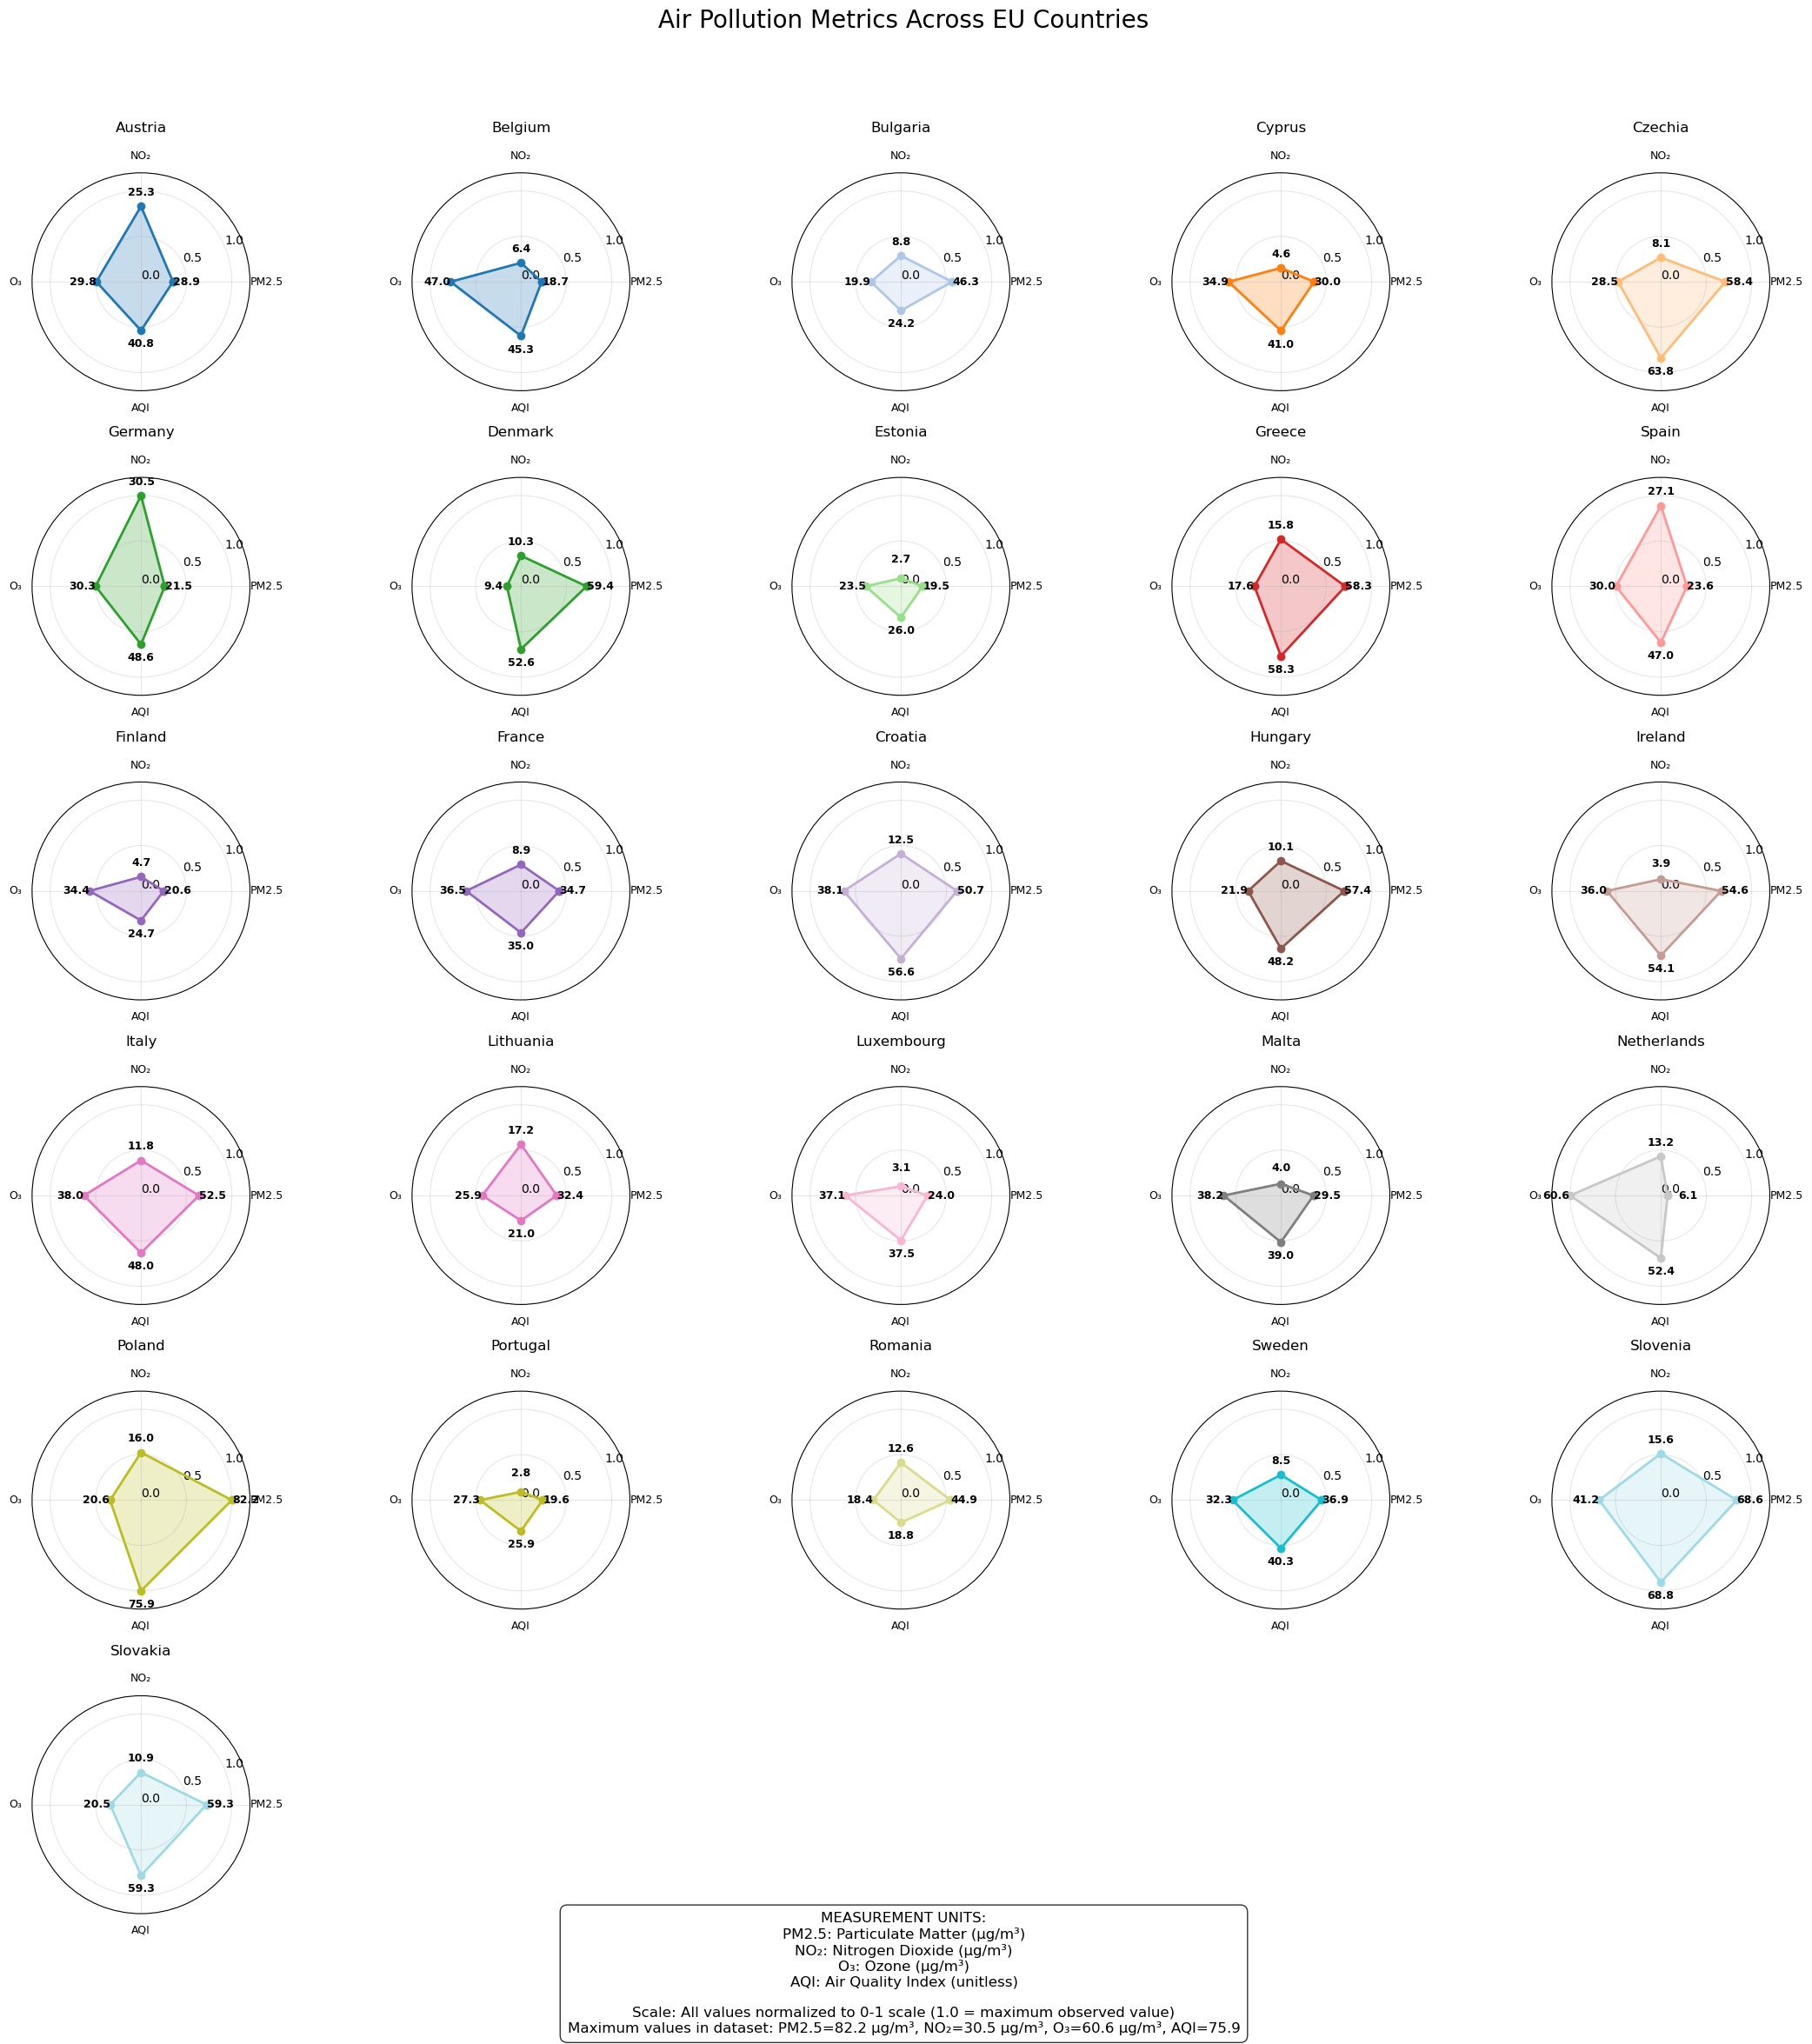

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

stations_df = pd.read_csv('station_measurements_concat.csv')

country_codes = stations_df['countryCode'].unique().tolist()
country_code_to_name = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'HR': 'Croatia', 'CY': 'Cyprus',
    'CZ': 'Czechia', 'DK': 'Denmark', 'EE': 'Estonia', 'EL': 'Greece', 'FI': 'Finland', 'FR': 'France',
    'DE': 'Germany', 'GR': 'Greece', 'HU': 'Hungary', 'IE': 'Ireland', 'IT': 'Italy',
    'LV': 'Latvia', 'LT': 'Lithuania', 'LU': 'Luxembourg', 'MT': 'Malta', 'NL': 'Netherlands',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SK': 'Slovakia', 'SI': 'Slovenia',
    'ES': 'Spain', 'SE': 'Sweden'
}

def radar_chart(categories, values, ax=None, **kw):
    if ax is None:
        ax = plt.gca()
        
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    

    values = values.tolist()
    values += values[:1]
    angles += angles[:1]
    

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)  
    
    
    ax.plot(angles, values, 'o-', linewidth=2, **kw)
    ax.fill(angles, values, alpha=0.25, **kw)
    
    
    ax.set_ylim(0, 1.2)  
    
    
    ax.set_rticks([0.0, 0.5, 1.0]) 
    ax.grid(True, alpha=0.3)
    
    return ax


all_countries = sorted(stations_df['countryCode'].unique().tolist())
country_data = stations_df[stations_df['countryCode'].isin(all_countries)]


pollutants = ['pm25', 'no2', 'o3', 'aqi']
country_stats = country_data.groupby('countryCode')[pollutants].mean()


for pollutant in pollutants:
    max_val = country_stats[pollutant].max()
    country_stats[f'{pollutant}_norm'] = country_stats[pollutant] / max_val


max_values = {p: country_stats[p].max() for p in pollutants}


n_countries = len(all_countries)
n_cols = min(5, n_countries)  # Max 5 charts per row
n_rows = math.ceil(n_countries / n_cols)


fig_height = 4 * n_rows  # 4 inches per row
fig = plt.figure(figsize=(22, fig_height))
categories = ['PM2.5', 'NO₂', 'O₃', 'AQI']


colors = plt.cm.tab20(np.linspace(0, 1, max(20, n_countries)))


plt.subplots_adjust(wspace=0.4, hspace=0.7)


for i, (country_code, color) in enumerate(zip(all_countries, colors)):
    if i >= len(all_countries):
        break
        
    ax = fig.add_subplot(n_rows, n_cols, i+1, projection='polar')
    
    
    country_name = country_code_to_name.get(country_code, country_code)
    
    
    if country_code in country_stats.index:
        values = country_stats.loc[country_code][[f'{p}_norm' for p in pollutants]]
        radar_chart(categories, values, ax=ax, color=color)
        
        
        for j, pollutant in enumerate(pollutants):
            angle = j * (2*np.pi/len(pollutants))
            norm_val = values[f'{pollutant}_norm']
            
            
            if not np.isfinite(norm_val):
                continue
                
            text_pos = max(norm_val + 0.15, 0.3)  # Position text with adequate spacing
            
            
            pollutant_val = country_stats.loc[country_code, pollutant]
            if np.isfinite(pollutant_val):
                ax.text(angle, text_pos, 
                        f"{pollutant_val:.1f}", 
                        ha='center', va='center', fontsize=9, fontweight='bold')
    else:
        
        ax.text(0, 0, "No data", ha='center', va='center')
    
    
    ax.set_title(f'{country_name}', size=12, pad=15)


legend_text = (
    "MEASUREMENT UNITS:\n"
    "PM2.5: Particulate Matter (μg/m³)\n"
    "NO₂: Nitrogen Dioxide (μg/m³)\n"
    "O₃: Ozone (μg/m³)\n"
    "AQI: Air Quality Index (unitless)\n\n"
    f"Scale: All values normalized to 0-1 scale (1.0 = maximum observed value)\n"
    f"Maximum values in dataset: PM2.5={max_values['pm25']:.1f} μg/m³, "
    f"NO₂={max_values['no2']:.1f} μg/m³, "
    f"O₃={max_values['o3']:.1f} μg/m³, "
    f"AQI={max_values['aqi']:.1f}"
)

plt.figtext(0.5, 0.01, legend_text, ha="center", fontsize=12, 
            bbox={"facecolor":"white", "alpha":0.8, "pad":5, "boxstyle":"round,pad=0.5"})

plt.suptitle('Air Pollution Metrics Across EU Countries', fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('all_countries_pollution_radar_charts.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import dash
from dash import dcc, html, Input, Output, dash_table
import plotly.graph_objects as go
import pandas as pd
import numpy as np


stations_df = pd.read_csv('station_measurements_concat.csv')


country_code_to_name = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'HR': 'Croatia', 'CY': 'Cyprus',
    'CZ': 'Czechia', 'DK': 'Denmark', 'EE': 'Estonia', 'EL': 'Greece', 'FI': 'Finland', 'FR': 'France',
    'DE': 'Germany', 'GR': 'Greece', 'HU': 'Hungary', 'IE': 'Ireland', 'IT': 'Italy',
    'LV': 'Latvia', 'LT': 'Lithuania', 'LU': 'Luxembourg', 'MT': 'Malta', 'NL': 'Netherlands',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SK': 'Slovakia', 'SI': 'Slovenia',
    'ES': 'Spain', 'SE': 'Sweden'
}


all_countries = sorted(stations_df['countryCode'].unique().tolist())
country_data = stations_df[stations_df['countryCode'].isin(all_countries)]


pollutants = ['pm25', 'no2', 'o3', 'aqi']
categories = ['PM2.5', 'NO₂', 'O₃', 'AQI']  
pollutant_units = ['μg/m³', 'μg/m³', 'μg/m³', '']  # Units for display

country_stats = country_data.groupby('countryCode')[pollutants].mean()


actual_values = country_stats.copy()


for pollutant in pollutants:
    max_val = country_stats[pollutant].max()
    country_stats[f'{pollutant}_norm'] = country_stats[pollutant] / max_val


max_values = {p: country_stats[p].max() for p in pollutants}


dropdown_options = [
    {'label': country_code_to_name.get(code, code), 'value': code} 
    for code in all_countries
]


app = dash.Dash(__name__)


app.layout = html.Div([
    html.H1("Air Pollution Comparison Across EU Countries", style={'textAlign': 'center'}),
    
    html.Div([
        html.Label("Select Countries to Compare:"),
        dcc.Dropdown(
            id='country-dropdown',
            options=dropdown_options,
            value=[all_countries[0], all_countries[1]],  # Default to first two countries
            multi=True
        ),
    ], style={'width': '60%', 'margin': 'auto', 'marginBottom': '20px', 'backgroundColor': 'white'}),
    
    
    dcc.Graph(id='radar-chart', style={'height': '700px', 'backgroundColor': 'white'}),
    
    
    html.Div([
        html.H3("Pollutant Statistics"),
        html.Div(id='stats-table')
    ], style={'marginTop': '20px', 'padding': '20px', 'backgroundColor': 'white'}),
    
], style={'backgroundColor': 'white', 'fontFamily': 'Arial', 'padding': '20px'})


@app.callback(
    Output('radar-chart', 'figure'),
    Input('country-dropdown', 'value')
)
def update_radar_chart(selected_countries):
    if not selected_countries:
        
        return go.Figure()
    
    
    fig = go.Figure()
    
    
    for country_code in selected_countries:
        if country_code not in country_stats.index:
            continue
            
        
        country_name = country_code_to_name.get(country_code, country_code)
        
        
        hovertext = []
        for i, cat in enumerate(categories):
            pollutant = pollutants[i]
            actual_val = actual_values.loc[country_code, pollutant]
            norm_val = country_stats.loc[country_code, f"{pollutant}_norm"]
            unit = pollutant_units[i]
            
            hover_line = f"{cat}: {actual_val:.1f}{unit} ({norm_val:.2f} normalized)"
            hovertext.append(hover_line)
        
        
        hovertext.append(hovertext[0])
        
        
        values = [country_stats.loc[country_code, f'{p}_norm'] for p in pollutants]
        
        
        values_closed = values + [values[0]]
        
        
        fig.add_trace(go.Scatterpolar(
            r=values_closed,
            theta=categories + [categories[0]],
            fill='toself',
            name=country_name,
            text=hovertext,
            hoverinfo='text+name'
        ))
    
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1.1],
                tickvals=[0, 0.25, 0.5, 0.75, 1.0],
                ticktext=['0', '0.25', '0.5', '0.75', '1.0'],
                gridcolor='#EEEEEE'  # Light gray grid
            ),
            angularaxis=dict(
                gridcolor='#EEEEEE'  # Light gray grid
            ),
            bgcolor='white'  # White background 
        ),
        showlegend=True,
        title="Air Quality Metrics Comparison",
        height=700,
        paper_bgcolor='white',  
        plot_bgcolor='white',   
        font=dict(
            family="Arial",
            color="black"
        )
    )
    
    return fig


@app.callback(
    Output('stats-table', 'children'),
    Input('country-dropdown', 'value')
)
def update_stats_table(selected_countries):
    if not selected_countries:
        return html.P("Select countries to view statistics")
    
    
    table_data = []
    for country_code in selected_countries:
        if country_code in actual_values.index:
            country_name = country_code_to_name.get(country_code, country_code)
            
            
            for i, p in enumerate(pollutants):
                actual_val = actual_values.loc[country_code, p]
                normalized_val = country_stats.loc[country_code, f"{p}_norm"]
                
                row = {
                    'Country': country_name,
                    'Pollutant': categories[i],
                    'Value': f"{actual_val:.1f} {pollutant_units[i]}",
                    'Normalized': f"{normalized_val:.2f}"
                }
                table_data.append(row)
    
    
    if table_data:
        return dash_table.DataTable(
            data=table_data,
            columns=[
                {'name': 'Country', 'id': 'Country'},
                {'name': 'Pollutant', 'id': 'Pollutant'},
                {'name': 'Value', 'id': 'Value'},
                {'name': 'Normalized', 'id': 'Normalized'}
            ],
            style_header={
                'backgroundColor': 'white',
                'fontWeight': 'bold',
                'borderBottom': '1px solid #DDDDDD'
            },
            style_cell={
                'textAlign': 'center',
                'backgroundColor': 'white',
                'color': 'black',
                'border': '1px solid #DDDDDD'
            },
            style_data_conditional=[
                {
                    'if': {'row_index': 'odd'},
                    'backgroundColor': '#F9F9F9'  # Very light gray for alternating rows
                }
            ],
            sort_action='native'
        )
    else:
        return html.P("No data available for selected countries")


if __name__ == '__main__':
    app.run(debug=True, port=8051)  

### Visualization 2 - Emissions over time with Facilities Data

In [2]:
import dash
from dash import dcc, html, Input, Output, callback, dash_table
import plotly.express as px
import pandas as pd
import numpy as np


facilities_df = pd.read_csv('facilities/facilities_cleaned.csv')


country_mapping = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'HR': 'Croatia', 'CY': 'Cyprus',
    'CZ': 'Czechia', 'DK': 'Denmark', 'EE': 'Estonia', 'FI': 'Finland', 'FR': 'France',
    'DE': 'Germany', 'EL': 'Greece', 'HU': 'Hungary', 'IE': 'Ireland', 'IT': 'Italy',
    'LV': 'Latvia', 'LT': 'Lithuania', 'LU': 'Luxembourg', 'MT': 'Malta', 'NL': 'Netherlands',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SK': 'Slovakia', 'SI': 'Slovenia',
    'ES': 'Spain', 'SE': 'Sweden', 'GR': 'Greece'
}


app = dash.Dash(__name__, 
                external_stylesheets=[{
                    'href': 'https://fonts.googleapis.com/css2?family=Open+Sans:wght@400;600&display=swap',
                    'rel': 'stylesheet'
                }])


app.layout = html.Div([
    html.H1("Emissions over time with Facility Data", 
            style={'textAlign': 'center', 'color': '#333', 'marginBottom': '30px',
                  'fontFamily': 'Open Sans, sans-serif'}),
    
    html.Div([
        html.Div([
            html.Label("Select Countries:", style={'fontWeight': 'bold', 'color': '#333'}),
            dcc.Dropdown(
                id='country-dropdown',
                options=[{'label': country_mapping.get(country, country), 'value': country} 
                         for country in sorted(facilities_df['countrycode'].unique())],
                value=['DE', 'FR', 'IT'],  # Default selected countries
                multi=True,
                style={'backgroundColor': 'white'}
            ),
        ], style={'width': '45%', 'display': 'inline-block', 'padding': '10px'}),
        
        html.Div([
            html.Label("Select Pollutant:", style={'fontWeight': 'bold', 'color': '#333'}),
            dcc.Dropdown(
                id='pollutant-dropdown',
                options=[
                    {'label': 'Nitrogen Dioxide (NO2)', 'value': 'NOX'},
                    {'label': 'Ozone (O3)', 'value': 'NMVOC'},
                    {'label': 'Carbon Dioxide (CO2)', 'value': 'CO2'}
                ],
                value='NOX',
                style={'backgroundColor': 'white'}
            ),
        ], style={'width': '45%', 'display': 'inline-block', 'padding': '10px'}),
        
        
        html.Div([
            html.Label("Emissions View:", style={'fontWeight': 'bold', 'color': '#333', 'marginRight': '10px'}),
            dcc.RadioItems(
                id='emissions-type',
                options=[
                    {'label': 'Total Emissions', 'value': 'total'},
                    {'label': 'Average per Facility', 'value': 'average'}
                ],
                value='total',
                inline=True,
                style={'color': '#333', 'padding': '5px'}
            ),
        ], style={'textAlign': 'center', 'padding': '10px', 'marginTop': '10px'})
    ], style={'backgroundColor': 'white', 'padding': '10px', 'borderRadius': '5px',
             'boxShadow': '0px 0px 5px rgba(0, 0, 0, 0.1)'}),
    
    dcc.Graph(id='time-series-chart', style={'backgroundColor': 'white'}),
    
    html.Div([
        html.H4("Statistics by Country and Year", 
                style={'color': '#333', 'fontFamily': 'Open Sans, sans-serif'}),
        html.Div(id='stats-table')
    ], style={'backgroundColor': 'white', 'padding': '15px', 'marginTop': '20px',
             'borderRadius': '5px', 'boxShadow': '0px 0px 5px rgba(0, 0, 0, 0.1)'})
], style={'backgroundColor': 'white', 'padding': '20px', 'fontFamily': 'Open Sans, sans-serif'})


@app.callback(
    Output('time-series-chart', 'figure'),
    [Input('country-dropdown', 'value'),
     Input('pollutant-dropdown', 'value'),
     Input('emissions-type', 'value')]
)
def update_graph(selected_countries, selected_pollutant, emissions_type):
    # Filter data
    filtered_df = facilities_df[
        (facilities_df['countrycode'].isin(selected_countries)) & 
        (facilities_df['pollutantcode'] == selected_pollutant)
    ]
    
    # Group by country and year with  aggregation
    if emissions_type == 'total':
        # Sum emissions by country and year
        grouped_df = filtered_df.groupby(['countrycode', 'reportingyear'])['releases'].sum().reset_index()
        y_axis_title = f"Total {selected_pollutant} Emissions"
    else:  # average
        # Calculate mean emissions by country and year
        grouped_df = filtered_df.groupby(['countrycode', 'reportingyear']).agg(
            releases=('releases', 'mean'),
            count=('releases', 'count')
        ).reset_index()
        y_axis_title = f"Average {selected_pollutant} Emissions per Facility"
    
    grouped_df['country_name'] = grouped_df['countrycode'].map(country_mapping)
    
    fig = px.line(
        grouped_df, 
        x='reportingyear', 
        y='releases', 
        color='country_name',
        markers=True,
        title=f"{selected_pollutant} {('Total' if emissions_type == 'total' else 'Average')} Emissions Over Time by Country",
        labels={'reportingyear': 'Year', 'releases': y_axis_title, 'country_name': 'Country'}
    )
    
    if emissions_type == 'average' and 'count' in grouped_df.columns:
        for i, trace in enumerate(fig.data):
            country = trace.name
            country_data = grouped_df[grouped_df['country_name'] == country]
            hovertemplate = '<b>%{customdata[0]}</b><br>Year: %{x}<br>Average: %{y:.2f}<br>Facilities: %{customdata[1]}<extra></extra>'
            trace.customdata = list(zip(country_data['country_name'], country_data['count']))
            trace.hovertemplate = hovertemplate
    else:
 
        for trace, country in zip(fig.data, grouped_df['country_name'].unique()):
            trace.hovertemplate = f'<b>{country}</b><br>Year: %{{x}}<br>Value: %{{y:.2f}}<extra></extra>'
    
  
    fig.update_layout(
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(
            tickmode='linear',
            gridcolor='#E4E4E4',
            zerolinecolor='#E4E4E4'
        ),
        yaxis=dict(
            gridcolor='#E4E4E4',
            zerolinecolor='#E4E4E4'
        ),
        legend=dict(
            bgcolor='rgba(255,255,255,0.9)',
            orientation='h', 
            yanchor='bottom', 
            y=1.02, 
            xanchor='right', 
            x=1
        ),
        margin=dict(l=40, r=40, t=60, b=40),
        hovermode='closest',
        font=dict(family="Open Sans, sans-serif", color="#333")
    )
    
    return fig

@app.callback(
    Output('stats-table', 'children'),
    [Input('country-dropdown', 'value'),
     Input('pollutant-dropdown', 'value'),
     Input('emissions-type', 'value')]
)
def update_stats_table(selected_countries, selected_pollutant, emissions_type):
    # Filter data
    filtered_df = facilities_df[
        (facilities_df['countrycode'].isin(selected_countries)) & 
        (facilities_df['pollutantcode'] == selected_pollutant)
    ]
    
    # Group by country and year
    grouped_df = filtered_df.groupby(['countrycode', 'reportingyear'])['releases'].agg(
        ['sum', 'mean', 'count', 'min', 'max']
    ).reset_index()
    

    grouped_df['sum'] = grouped_df['sum'].round(2)
    grouped_df['mean'] = grouped_df['mean'].round(2)
    grouped_df['min'] = grouped_df['min'].round(2)
    grouped_df['max'] = grouped_df['max'].round(2)
    

    grouped_df['country'] = grouped_df['countrycode'].map(country_mapping)
    
    
    display_df = grouped_df[['country', 'reportingyear', 'sum', 'mean', 'count', 'min', 'max']]
    
  
    display_df.columns = ['Country', 'Year', 'Total Emissions', 'Average', 'Facilities Count', 'Min', 'Max']
    
   
    highlighted_column = 'Total Emissions' if emissions_type == 'total' else 'Average'
    

    table = dash_table.DataTable(
        data=display_df.to_dict('records'),
        columns=[{'name': col, 'id': col} for col in display_df.columns],
        style_header={
            'backgroundColor': 'white',
            'fontWeight': 'bold',
            'border': '1px solid #ddd',
            'textAlign': 'center'
        },
        style_cell={
            'backgroundColor': 'white',
            'color': 'black',
            'border': '1px solid #ddd',
            'textAlign': 'center',
            'padding': '8px'
        },
        style_data_conditional=[
            {
                'if': {'row_index': 'odd'},
                'backgroundColor': '#f9f9f9'
            },
            
            {
                'if': {'column_id': highlighted_column},
                'backgroundColor': '#e6f3ff',  # Light blue highlight
                'fontWeight': 'bold'
            }
        ],
        sort_action='native',
        page_action='native',
        page_size=10,
    )
    
    return table

if __name__ == '__main__':
    app.run(debug=True, port=8051)  

### Visualization 3 - Interactive Map of Facilities and nearby air quality stations

In [6]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from math import radians, cos
import geopy.distance
import branca.colormap as cm


stations_df = pd.read_csv('station_measurements_concat.csv')
facilities_df = pd.read_csv('facilities/facilities_cleaned.csv')

def find_nearby_facilities_map_by_year(stations_df, facilities_df, max_distance=1):

    valid_facilities = facilities_df[
        (facilities_df['latitude'].notna()) & 
        (facilities_df['longitude'].notna()) &
        (facilities_df['latitude'] != 0) & 
        (facilities_df['longitude'] != 0)
    ]
    
    
    m = folium.Map(location=[50.0, 10.0], zoom_start=4)
    
    
    station_cluster = MarkerCluster(name="Air Quality Stations").add_to(m)
    
    
    years = sorted(valid_facilities['reportingyear'].unique())
    
    
    colors = [
        'red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightblue', 
        'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'pink', 'lightred',
        'beige', 'lightgreen', 'gray', 'black', 'lightgray', 'maroon',
        'white', 'salmon', 'teal', 'gold', 'olive', 'navy', 'brown', 'lime'
    ]
    year_colors = {year: colors[i % len(colors)] for i, year in enumerate(years)}
    
 
    facility_clusters = {}
    for year in years:
        cluster_name = f"Industrial Facilities - {year}"
        
        show_layer = (year == max(years))
        facility_clusters[year] = MarkerCluster(name=cluster_name, show=show_layer).add_to(m)
    
    
    added_facilities_by_year = {year: set() for year in years}
    
    
    stations_with_nearby_facilities = 0
    total_nearby_facilities = 0
    stats_by_year = {year: {"facilities": 0} for year in years}
    
    
    for _, station in stations_df.iterrows():
        
        if pd.isna(station['lat']) or pd.isna(station['lon']):
            continue
        
        #
        station_name = f"Station {station['station_id']}"
        if pd.notna(station['city']) and station['city']:
            station_name = f"{station['city']} ({station['countryCode']})"
        
        
        popup_content = f"""
        <b>{station_name}</b><br>
        Station ID: {station['station_id']}<br>
        Region: {station['region'] if pd.notna(station['region']) else 'Unknown'}<br>
        PM2.5: {station['pm25'] if pd.notna(station['pm25']) else 'Not measured'}<br>
        AQI: {station['aqi'] if pd.notna(station['aqi']) else 'Not measured'}<br>
        NO2: {station['no2'] if pd.notna(station['no2']) else 'Not measured'}<br>
        O3: {station['o3'] if pd.notna(station['o3']) else 'Not measured'}<br>
        """
        
        
        station_marker = folium.Marker(
            location=[station['lat'], station['lon']],
            popup=folium.Popup(popup_content, max_width=300),
            icon=folium.Icon(color='blue', icon='cloud', prefix='fa'),
            tooltip=f"Station: {station_name}"
        )
        station_cluster.add_child(station_marker)
        
        
        lat_radius = 2 / 111.0  
        lon_radius = 2 / (111.0 * abs(cos(radians(station['lat']))))
        
        nearby_facilities = valid_facilities[
            (valid_facilities['latitude'] >= station['lat'] - lat_radius) &
            (valid_facilities['latitude'] <= station['lat'] + lat_radius) &
            (valid_facilities['longitude'] >= station['lon'] - lon_radius) &
            (valid_facilities['longitude'] <= station['lon'] + lon_radius)
        ]
        
        if len(nearby_facilities) == 0:
            continue
            
        
        nearby_facilities['distance'] = nearby_facilities.apply(
            lambda row: geopy.distance.geodesic(
                (station['lat'], station['lon']),
                (row['latitude'], row['longitude'])
            ).km,
            axis=1
        )
        
        
        close_facilities = nearby_facilities[nearby_facilities['distance'] <= max_distance]
        
        if len(close_facilities) > 0:
            stations_with_nearby_facilities += 1
        
        
        for _, facility in close_facilities.iterrows():
            facility_id = facility['release_id']
            year = facility['reportingyear']
            total_nearby_facilities += 1
            
            
            if facility_id not in added_facilities_by_year[year]:
                facility_name = facility['facilityname']
                
                
                popup_content = f"""
                <b>{facility_name}</b><br>
                Facility ID: {facility_id}<br>
                Reporting Year: {year}<br>
                Sector: {facility['eprtr_sectorname']}<br>
                Pollutant: {facility['pollutantcode']}<br>
                City: {facility['city']}<br>
                Country: {facility['countrycode']}<br>
                Releases: {facility['releases']}<br>
                Distance to Station: {facility['distance']:.3f} km
                """
                
                
                facility_marker = folium.Marker(
                    location=[facility['latitude'], facility['longitude']],
                    popup=folium.Popup(popup_content, max_width=300),
                    icon=folium.Icon(color=year_colors[year], icon='industry', prefix='fa'),
                    tooltip=f"Facility: {facility_name} ({year})"
                )
                facility_clusters[year].add_child(facility_marker)
                added_facilities_by_year[year].add(facility_id)
                stats_by_year[year]["facilities"] += 1
    
    
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white; 
                padding: 10px; border: 2px solid grey; border-radius: 5px">
        <p><b>Legend</b></p>
        <p>
            <i class="fa fa-cloud" style="color: blue"></i> Air Quality Station<br>
    '''
    
    
    for year in sorted(years):
        legend_html += f'''
            <i class="fa fa-industry" style="color: {year_colors[year]}"></i> Industrial Facility ({year})<br>
        '''
    
    legend_html += '''
        </p>
    </div>
    '''
    
    
    m.get_root().html.add_child(folium.Element(legend_html))
    
    
    title_html = f'''
        <h3 align="center" style="font-size:16px">
            <b>Air Quality Stations & Nearby Industrial Facilities (≤{max_distance}km) by Year</b><br>
            <span style="font-size:12px">
                {stations_with_nearby_facilities} stations with nearby facilities | 
                {total_nearby_facilities} total facilities within {max_distance}km of stations
            </span>
        </h3>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    
    folium.LayerControl().add_to(m)
    
    return m, {
        "stations_with_nearby_facilities": stations_with_nearby_facilities,
        "total_nearby_facilities": total_nearby_facilities,
        "stats_by_year": stats_by_year
    }


proximity_map, stats = find_nearby_facilities_map_by_year(stations_df, facilities_df, max_distance=1)


filename = "stations_facilities_1km_by_year.html"
proximity_map.save(filename)


print(f"Map created showing all facilities within 1km of any air quality station, with layers by year.")
print(f"Statistics:")
print(f"- {stats['stations_with_nearby_facilities']} stations have facilities within 1km")
print(f"- {stats['total_nearby_facilities']} total facilities within 1km of stations")

print("\nBreakdown by year:")
for year, year_stats in stats['stats_by_year'].items():
    if year_stats['facilities'] > 0:
        print(f"  Year {year}: {year_stats['facilities']} unique facilities")

print(f"\nMap saved as '{filename}'")

C:\Users\danie\AppData\Local\Temp\ipykernel_3496\2716117230.py:101: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\danie\AppData\Local\Temp\ipykernel_3496\2716117230.py:101: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\danie\AppData\Local\Temp\ipykernel_3496\2716117230.py:101: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

Map created showing all facilities within 1km of any air quality station, with layers by year.
Statistics:
- 210 stations have facilities within 1km
- 7870 total facilities within 1km of stations

Breakdown by year:
  Year 2007: 533 unique facilities
  Year 2008: 549 unique facilities
  Year 2009: 541 unique facilities
  Year 2010: 528 unique facilities
  Year 2011: 506 unique facilities
  Year 2012: 483 unique facilities
  Year 2013: 457 unique facilities
  Year 2014: 458 unique facilities
  Year 2015: 450 unique facilities
  Year 2016: 434 unique facilities
  Year 2017: 438 unique facilities
  Year 2018: 436 unique facilities
  Year 2019: 400 unique facilities
  Year 2020: 367 unique facilities
  Year 2021: 376 unique facilities
  Year 2022: 373 unique facilities
  Year 2023: 330 unique facilities

Map saved as 'stations_facilities_1km_by_year.html'
